# 03 · The Assumption-Free Tests

Notebook 02 showed the Student t-test rejecting 37.5% of the time on data with no real
difference, and Welch running above α on skewed unbalanced data. Both failures come from the
same source: a test that *assumes* a null distribution instead of finding out what it is.

There is another way. Four of them, in fact.

| Test | Idea | Assumes |
|---|---|---|
| **Permutation** | shuffle the group labels, rebuild the null from the data | nothing about shape |
| **Bootstrap** | resample each group, read the interval of the difference | nothing about shape |
| **Mann-Whitney U** | compare ranks, not values | nothing about shape (but a *different* hypothesis) |
| **Welch** | the t-test without the equal-variance assumption | normality |

This notebook builds each one on the exact data that broke the Student t-test.

In [1]:
# Make the project importable whether this notebook is run from notebooks/ or the repo root.
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from functools import partial

import numpy as np

from src.config import get_settings, save_results
from src.evaluation import derive_seed, name_key
from src.evaluation.false_positive import false_positive_rate
from src.evaluation.comparison import run_arena
from src.simulation.scenarios import base_scenarios
from src.tests import mean_difference
from src.tests.bootstrap import bootstrap_distribution, bootstrap_test
from src.tests.mann_whitney import mann_whitney_test
from src.tests.permutation import permutation_null_distribution, permutation_test
from src.visualisation import (
    plot_bootstrap_distribution,
    plot_false_positive_rates,
    plot_null_distribution,
    save_figure,
)

settings = get_settings()
alpha, n_reps = settings.alpha, settings.reps.n_reps
n_perm, n_boot = settings.reps.n_perm, settings.reps.n_boot
null_grid = [s.with_effect(0.0) for s in base_scenarios(settings)]
scenarios = {s.name.split("::")[0]: s for s in null_grid}
figures: dict[str, str] = {}

demo = scenarios["normal_unequal_var_unequal_n"]
a, b = demo.draw(np.random.default_rng(settings.notebooks.demo_seed))
print(f"the data that broke Student: n={demo.n_a}/{demo.n_b}, sd ratio {demo.sd_ratio}, "
      f"true difference {demo.true_mean_difference}")

the data that broke Student: n=100/15, sd ratio 4.0, true difference 0.0


## 1 · The permutation test

If the two groups really come from the same distribution, the labels "a" and "b" are arbitrary.
So shuffle them, recompute the statistic, and repeat a few hundred times. That collection of
values **is** the null distribution — not assumed, constructed from the data in hand.

Then ask where the observed value falls in it.

observed statistic: 0.2712
shuffles at least as extreme: 1620 of 2000
p = (1 + count) / (n_perm + 1) = 0.8101
smallest p this many shuffles can produce: 0.0005


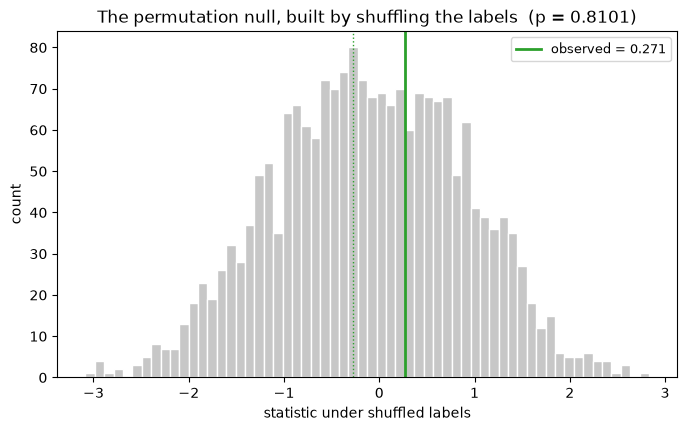

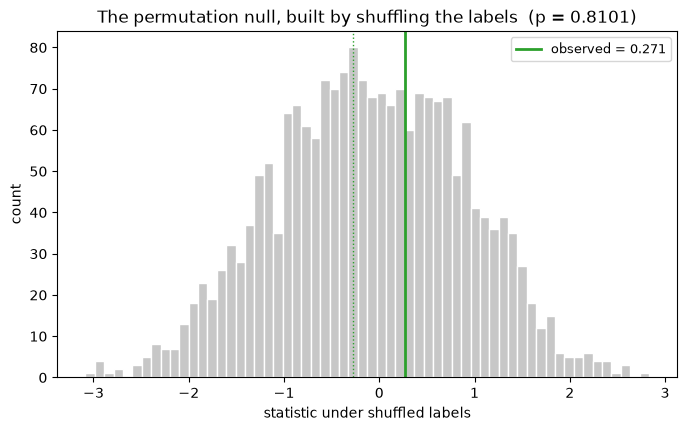

In [3]:
null = permutation_null_distribution(a, b, n_perm=2000, rng=np.random.default_rng(1))
result = permutation_test(a, b, n_perm=2000, alpha=alpha, rng=np.random.default_rng(1))

print(f"observed statistic: {result.statistic:.4f}")
print(f"shuffles at least as extreme: {int(result.extra['n_at_least_as_extreme'])} of 2000")
print(f"p = (1 + count) / (n_perm + 1) = {result.p_value:.4f}")
print(f"smallest p this many shuffles can produce: {result.extra['min_attainable_p']:.4f}")

fig = plot_null_distribution(null, result.statistic, p_value=result.p_value)
figures["permutation_null"] = save_figure(fig, "03_permutation_null")
fig

Two details in that output that matter more than they look.

**The p-value has a `1 +` in it.** With 2,000 shuffles the smallest p-value that can honestly be
reported is 1/2001. Dividing without the correction would let the test report `p = 0`, which
claims more evidence than was gathered.

**The statistic being shuffled is the Welch t, not the raw difference in means.** This is not a
detail. A permutation test on the raw mean difference is only exact when the two distributions
are *identical*; with unequal variances and unequal group sizes it fails in the same direction
Student does. Studentizing fixes it, and here is the measurement:

In [4]:
variants = {
    "permutation (mean difference)": partial(
        permutation_test, n_perm=n_perm, statistic=mean_difference
    ),
    "permutation (Welch t, the default)": partial(permutation_test, n_perm=n_perm),
}
studentization = {}
for name, test_fn in variants.items():
    r = false_positive_rate(
        test_fn, demo, n_reps=n_reps, alpha=alpha,
        data_seed=derive_seed(settings.seed, name_key(demo.name)),
        test_seed=derive_seed(settings.seed, name_key(demo.name), name_key("permutation")),
        test_name=name,
    )
    studentization[name] = r.rate
    print(f"{name:<36} false-positive rate {r.rate:.4f} ± {2 * r.mc_se:.4f}")

permutation (mean difference)        false-positive rate 0.3672 ± 0.0096


permutation (Welch t, the default)   false-positive rate 0.0509 ± 0.0044


Shuffling raw mean differences is *not* assumption-free in the way people assume: it assumes
exchangeability, which unequal variances break. Studentising restores it.

## 2 · The bootstrap

The permutation test answers "is this difference bigger than chance?". The bootstrap answers a
better question: **how big is the difference, and how sure are we?**

Resample each group with replacement, recompute the difference, and read the interval off the
resampling distribution directly.

observed difference: 0.2288
95% percentile interval: [-1.2375, 1.9902]
interval excludes zero? False   (this is a CI-inversion decision, not a p-value)


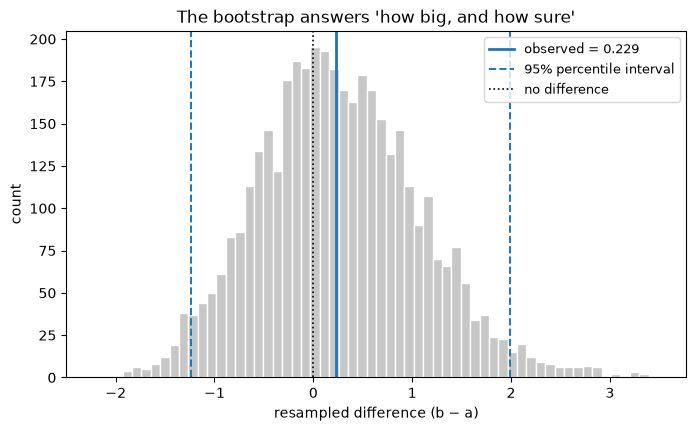

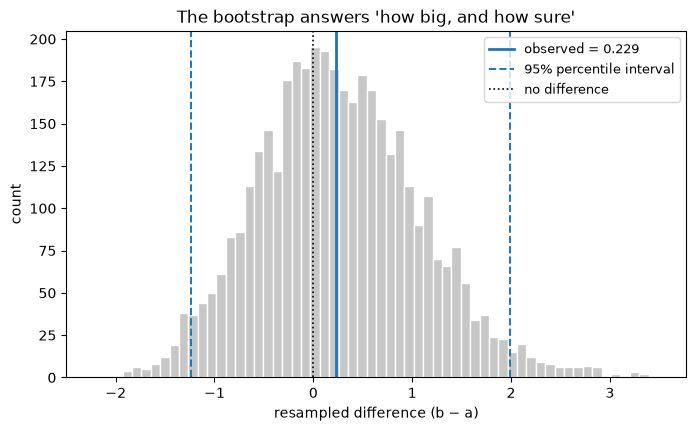

In [5]:
# bootstrap_test and bootstrap_distribution resample in the same order, so seeding both with
# the same generator makes the histogram below exactly the distribution the interval came from.
boot = bootstrap_test(a, b, n_boot=4000, alpha=alpha, rng=np.random.default_rng(2))
boot_draws = bootstrap_distribution(a, b, n_boot=4000, rng=np.random.default_rng(2))
print(f"observed difference: {boot.effect:.4f}")
print(f"95% percentile interval: [{boot.ci[0]:.4f}, {boot.ci[1]:.4f}]")
print(f"interval excludes zero? {boot.reject}   (this is a CI-inversion decision, not a p-value)")

fig = plot_bootstrap_distribution(boot_draws, boot.effect, boot.ci)
figures["bootstrap_distribution"] = save_figure(fig, "03_bootstrap_distribution")
fig

The interval straddles zero, so there is no detectable difference — which is correct, because
there is no difference. But notice what you get for free: a *range* for the effect, on the scale
of the data. A range for the effect is a more useful thing to report than "not significant",
and it is the same computation either way.

## 3 · Mann-Whitney U — and the caveat that must travel with it

Replace every value by its rank in the pooled sample and ask whether one group's ranks tend to
be higher. Outliers become "the largest rank" instead of "a number 40 standard deviations out",
so the test is naturally robust.

**But it is not testing the same hypothesis.** Mann-Whitney tests *stochastic dominance* — the
probability that a random draw from b exceeds a random draw from a. On symmetric distributions
with a pure location shift that coincides with "the means differ". Under skew or unequal spread
it does not, and reading a Mann-Whitney rejection as a statement about means is an error.

In [6]:
mwu = mann_whitney_test(a, b, alpha=alpha)
print(f"U (for group b) = {mwu.statistic:.1f}")
print(f"P(b > a) = {mwu.extra['prob_superiority']:.4f}   (0.5 means neither group dominates)")
print(f"rank-biserial correlation = {mwu.extra['rank_biserial']:.4f}")
print(f"p = {mwu.p_value:.4f}")
print()
print("Note: no confidence interval is reported. An interval for the mean difference would")
print("misrepresent what this test estimates.")

U (for group b) = 737.0
P(b > a) = 0.4913   (0.5 means neither group dominates)
rank-biserial correlation = -0.0173
p = 0.9173

Note: no confidence interval is reported. An interval for the mean difference would
misrepresent what this test estimates.


## 4 · All of them, on the data that broke Student

Three null conditions, six tests, ten thousand replications each. Everything below should sit on
the dashed line at α = 0.05.

In [7]:
chosen = [
    scenarios["normal_unequal_var_unequal_n"],
    scenarios["skewed_small_n"],
    scenarios["contaminated_outliers"],
]
rates = run_arena(chosen, settings=settings)
rates.pivot(index="scenario", columns="test", values="reject_rate").round(4)

test,bayesian,bootstrap,mann_whitney,permutation,student,welch
scenario,,,,,,
contaminated_outliers::null,0.0407,0.0204,0.0488,0.0490,0.0432,0.0426
normal_unequal_var_unequal_n::null,0.0488,0.0441,0.1721,0.0509,0.3753,0.0477
skewed_small_n::null,0.0337,0.0280,0.0430,0.0496,0.0402,0.0372


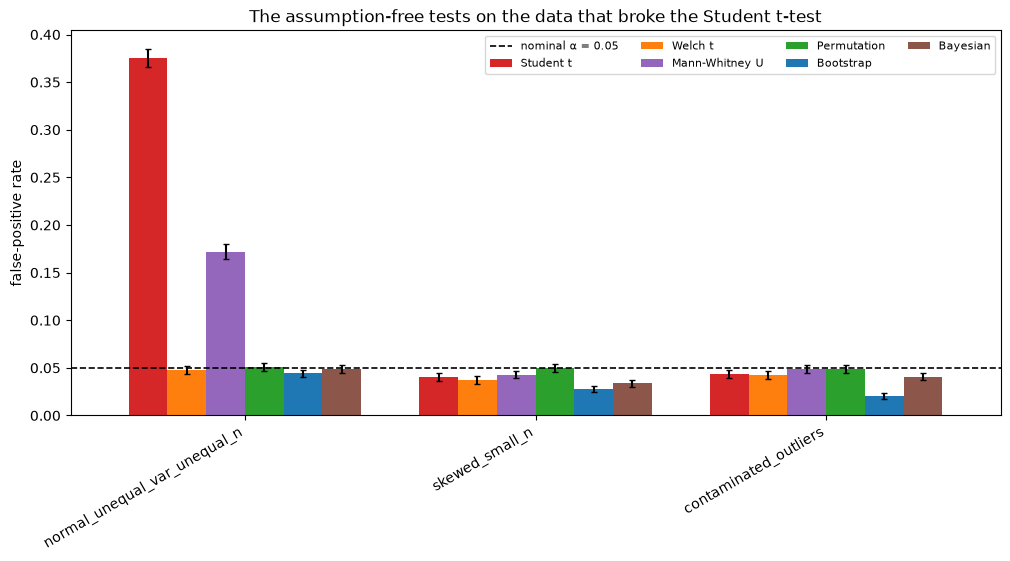

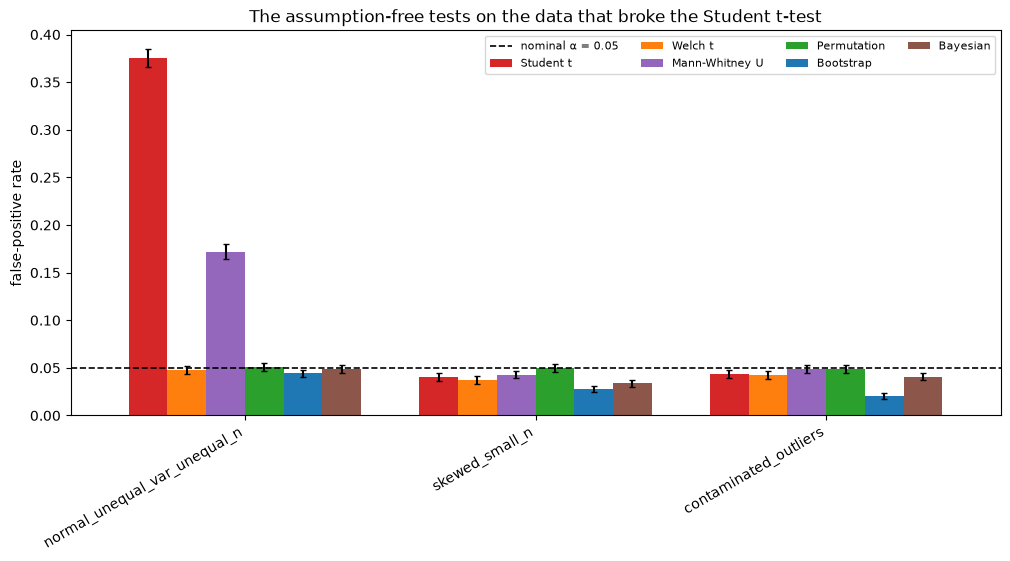

In [8]:
fig = plot_false_positive_rates(rates, alpha=alpha)
fig.axes[0].set_title("The assumption-free tests on the data that broke the Student t-test")
figures["fpr_assumption_free"] = save_figure(fig, "03_fpr_assumption_free")
fig

Read it carefully, because it is not a clean sweep and should not be presented as one.

- **Permutation** holds α in all three. This is the one that just works.
- **Welch** fixes the variance case that broke Student, as promised.
- **Bootstrap** never runs hot, but on skewed and contaminated data it is *conservative* — it
  rejects less than 5%, which is safe but costs power. That is the price of studentising its
  null-shifted p-value, and it is a real cost, not a rounding error.
- **Mann-Whitney** rejects 17% of the time in the first column — and it is *not wrong to*.
  Those two populations have the same mean but different spreads, so they are genuinely
  different distributions, and a test of stochastic equality should say so. This is the estimand
  caveat with a number attached: if you read that 17% as "Mann-Whitney has a false-positive
  problem" you have mistaken its hypothesis for the t-test's. If you were asking about means,
  though, those rejections are the wrong answer to your question — which is the real lesson.
- **Bayesian** tracks Welch closely, which is expected: with reference priors this is the
  Behrens–Fisher problem.

## What we have established

- The permutation test builds the null from the data and holds α wherever it was tried here.
- Studentising matters; "permutation test" without it is not automatically safe.
- The bootstrap gives an interval for the effect, which is usually the thing worth reporting.
- Mann-Whitney is robust but answers a different question, and that has to be said out loud.
- A resampling p-value can never be zero.

Next: all six tests across the whole grid.

In [9]:
summary = {
    "notebook": "03_the_assumption_free_tests",
    "settings": {"profile": settings.profile, "alpha": alpha, "n_reps": n_reps,
                 "n_perm": n_perm, "n_boot": n_boot, "seed": settings.seed},
    "demonstration_dataset": {
        "scenario": demo.name, "n_a": demo.n_a, "n_b": demo.n_b,
        "sd_ratio": demo.sd_ratio, "true_mean_difference": demo.true_mean_difference,
    },
    "permutation_example": {
        "statistic": result.statistic,
        "p_value": result.p_value,
        "n_perm": result.extra["n_perm"],
        "n_at_least_as_extreme": result.extra["n_at_least_as_extreme"],
        "min_attainable_p": result.extra["min_attainable_p"],
    },
    "studentization_effect": studentization,
    "bootstrap_example": {
        "effect": boot.effect, "ci_low": boot.ci[0], "ci_high": boot.ci[1],
        "reject": boot.reject, "n_boot": 4000,
    },
    "mann_whitney_example": {
        "u": mwu.statistic, "p_value": mwu.p_value,
        "prob_superiority": mwu.extra["prob_superiority"],
        "rank_biserial": mwu.extra["rank_biserial"],
    },
    "false_positive_rates": rates,
    "figures": figures,
    "claims": [
        "The permutation test builds its null distribution by shuffling the group labels, so it "
        "assumes nothing about the shape of either distribution.",
        "Its p-value uses the add-one correction, so with B shuffles the smallest reportable "
        "p-value is 1/(B+1) and never zero.",
        "Permuting raw mean differences is NOT safe under unequal variance with unequal n "
        f"({studentization['permutation (mean difference)']:.3f} against a nominal {alpha}); "
        "permuting Welch t statistics is "
        f"({studentization['permutation (Welch t, the default)']:.3f}).",
        "The bootstrap reports an interval for the size of the difference, which is more useful "
        "than a significance verdict.",
        "Mann-Whitney tests stochastic dominance, not a difference in means; the distinction "
        "only disappears under a pure location shift on symmetric data.",
        "On the data that broke Student, the studentized permutation test holds alpha while the "
        "bootstrap is conservative on skewed and contaminated data.",
    ],
}
print(save_results("03_the_assumption_free_tests", summary))

/workspaces/hypothesis_testing_arena/outputs/results/03_the_assumption_free_tests.json
